**Instituto Tecnológico de Aeronáutica – ITA**

**Aprendizado Profundo – CM-204**

**Professor:** 

Marcos Ricardo Omena de Albuquerque Maximo

# Laboratório 3 – Redes Neurais Convolucionais

**Observação: Não** exclua células, pois isto pode gerar problemas para o autocorretor.

# 1. Introdução
 
Nesse laboratório, seu objetivo é implementar, treinar e testar a rede neural LeNet-5 usando o dataset MNIST.  O MNIST consiste num conjunto grande de imagens anotadas de dígitos decimais escritos à mão. Assim, você reproduzirá um trabalho clássico da Literatura de Redes Neurais Convolucionais (CNNs), que foi realizado originalmente por Yann LeCun. A Figura 1 apresenta uma das imagens do MNIST juntamente com o *label* esperado (de acordo com a anotação) e o *label* predito pela LeNet-5.

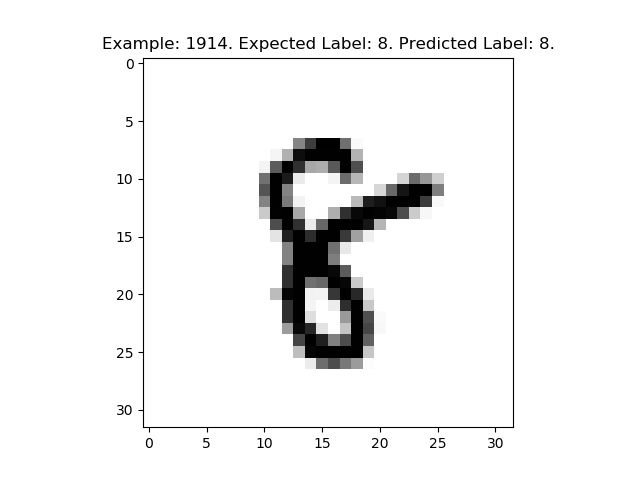

**Figura 1**: exemplo de dígito escrito à mão do *dataset* MNIST.


# 2. Descrição do Problema

O problema a ser resolvido nesse laboratório é implementar, treinar e testar a rede LeNet-5 no *dataset* MNIST. Para isso, você deve usar a *framework* PyTorch. A Tabela 1 apresenta uma descrição da rede LeNet-5. A entrada da rede é (32, 32, 1), em que os números representam largura, altura e número de canais de cor da imagem, respectivamente. Para ajuda em como implementar cada uma dessas camadas usando PyTorch, recomenda-se verificar a Seção 6 (Dicas). Além disso, destaca-se que o aluno pode encontrar algumas interpretações mais modernas da LeNet-5 na Internet, mas pede-se para implementar a arquitetura dessa rede conforme descrito na Tabela 1.


|**Camada**|**Tipo**|**Número de Filtros**|**Tamanho da Saída**|**Tamanho do Kernel**|***Stride***|***Activation Function***|
|:------|:----------------|:--|:----|:---|:-|:------|
|Entrada|Imagem           |1  |32x32|-   |- |-      |
|1      |Conv2D           |6  |28x28|5x5 |1 |tanh   |
|2      |AveragePooling2D |6  |14x14|2x2 |2 |-      |
|3      |Conv2D           |16 |10x10|5x5 |1 |tanh   |
|4      |AveragePooling2D |16 |5x5  |2x2 |2 |-      |
|5      |Conv2D           |120|1x1  |5x5 |1 |tanh   |
|6      |*Dense* (FC)     |-  |84   |-   |- |tanh   |
|7      |*Dense* (FC)     |-  |10   |-   |- |softmax|

<p align="center">
<b>Tabela 1</b>: arquitetura da LeNet-5. </p>

# 3. Código Base

O código base fornece diversas implementações para facilitar o uso do NMIST e o treinamento e avaliação da LeNet-5. Você precisa apenas editar a Seção 4.3, onde deve ser implementada a LeNet-5.


# 4. Tarefas

Comece o laboratório executando a célula abaixo com uma função auxiliar para mostrar uma imagem do MNIST. **Não há necessidade de alterá-la**.

In [ ]:
import matplotlib.pyplot as plt


def display_image(image, title):
    image = image.squeeze()
    plt.figure()
    plt.title(title)
    plt.imshow(image, cmap=plt.cm.gray_r)

## 4.1.	*Download* do NMIST

Execute a célula abaixo para fazer o *download* do MNIST. Observe-se que se define uma transformação envolvendo *padding* pois as imagens do MNIST são 28x28, enquanto a LeNet5 usa entrada 32x32.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# transformations
transform = transforms.Compose([
    transforms.Pad(2), # pad 28x28 px images to 32x32 px
    transforms.ToTensor(), # converts to [0,1]
])

# datasets
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

## 4.2.	Exploração do NMIST

Execute o a célula abaixo para explorar o NMIST. Alguns dados sobre o *training* e *test sets* serão mostradas. Além disso, são mostradas algumas imagens aleatórias. **Não há necessidade de incluir essas imagens no seu relatório**.


In [ ]:
import random
import matplotlib.pyplot as plt

random.seed(42)

NUM_IMAGES = 10

print('# of training images:', len(train_dataset))
print('# of test images:', len(test_dataset))

for i in range(NUM_IMAGES):
    index = random.randint(0, len(train_dataset))
    image, label = train_dataset[index]
    display_image(image, 'Example: %d. Label: %d' % (index, label))

plt.show()

## 4.3. Implementação da LeNet-5

Usando PyTorch, implemente a arquitetura LeNet-5 de acordo com a arquitetura apresentada na Tabela 1. Veja as dicas na Seção 6 para te ajudar. **Observações**:

- Não há necessidade de se preocupar com regularização ou normalização para o correto treinamento da rede.

- A implementação da LeNet-5 é muito simples usando PyTorch. Serão poucas linhas de código.

- Como essa é uma rede muito clássica, há diversos lugares na *Internet* com implementações dela. Porém, recomendo que você tente implementar você mesmo a rede ao invés de procurar código já pronto. Além disso, perceba que a rede deve ser implementada exatamente conforme mostrado na Tabela 1.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    '''
    Class to define the architecture of the CNN model.
    '''
    def __init__(self):
        '''
        Initializes the layers of the CNN model.
        '''
        super(CNN, self).__init__()
        # Create the layers and store them into the object

    def forward(self, x : torch.Tensor) -> torch.Tensor:
        '''
        Defines the forward pass of the CNN model.
        Args:
            x: Input tensor to the neural network.
        Returns:
            Output tensor of the neural network.
        '''
        # Implement the forward pass of the neural network
        # Obs.: Do not add the softmax activation function at the end, as it is included in the loss function (CrossEntropyLoss)!
        return x


## 4.4. Treinamento da LeNet-5

Treine a LeNet-5 implementada. Leia o código fornecido e tente entender o que está sendo feito. Perceba que a implementação separa o *training set* original, deixando algumas imagens para um *validation set*.


### Treinamento da LeNet-5


A célula a seguir verifica se você tem suporte a algum dispositivo acelerador, como uma GPU, e o seleciona. Caso contrário, escolhe-se a CPU como dispositivo (`device`) para o PyTorch.

In [ ]:
# Check for NVIDIA (CUDA) or Apple Silicon (MPS), otherwise fallback to CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available(): # For Mac users
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

A célula a seguir cria os `dataloaders` para realizar a interação com os conjuntos de dados durante o treinamento.

In [ ]:
BATCH_SIZE = 128

# dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

A célula a seguir apresenta um sumário da rede para que você possa verificar se a sua implementação está correta. Perceba que 128 é o tamanho do *mini-batch* (`BATCH_SIZE`).

In [ ]:
import torchinfo

model = CNN()
torchinfo.summary(model, input_size=(BATCH_SIZE, 1, 32, 32))

A célula a seguir treina a rede neural, enquanto guarda o histórico do treinamento para posterior análise.

In [ ]:
from time import time
from tqdm import tqdm
import torch
import numpy as np

NUM_EPOCHS = 20

print('# of training images:', len(train_dataset))
print('# of test images:', len(test_dataset))

# Build and compile model
model = CNN()
model = model.to(device)
torchinfo.summary(model, input_size=(BATCH_SIZE, 1, 32, 32))

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

history = np.zeros((NUM_EPOCHS, 4))

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0
    
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()
    
    train_loss = train_loss / len(train_loader.dataset)
    train_accuracy = train_correct / len(train_loader.dataset)
    history[epoch, 0] = train_loss
    history[epoch, 1] = train_accuracy

    model.eval()
    test_loss = 0.0
    test_correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * images.size(0)
            test_correct += (outputs.argmax(dim=1) == labels).sum().item()

    test_loss = test_loss / len(test_loader.dataset)
    test_accuracy = test_correct / len(test_loader.dataset)
    history[epoch, 2] = test_loss
    history[epoch, 3] = test_accuracy

    print(f'Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}')

torch.save(model.state_dict(), 'lenet5.pth')

O código a seguir apresenta as curvas de treinamento da rede, considerando os conjuntos de treinamento e de teste. Inclua estes gráficos no relatório e comente os resultados obtidos.

Caso você obtenha uma curva de treinamento pior que a de teste no começo do treinamento, não se assuste. Neste caso, isto acontece porque a rede aprende a cada *mini-batch* durante a *epoch*, de modo que a *loss* calculada é um desempenho "médio" das várias versões da rede ao longo da *epoch*. Já o desempenho no conjunto de teste é avaliado usando apenas a última versão da rede (ao final da *epoch*).

In [ ]:
plt.figure()
plt.plot(history[:, 0], label='Train Loss')
plt.plot(history[:, 2], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.savefig('results/loss.png', format='png')
plt.figure()
plt.plot(history[:, 1], label='Train Accuracy')
plt.plot(history[:, 3], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.savefig('results/accuracy.png', format='png')

plt.show()

## 4.5. Avaliação da LeNet-5

Avalie a LeNet-5 no *test set* executando a célula abaixo. Além de exibir alguns exemplos aleatórios, incluindo o *label* anotado e o *label* predito pela LeNet-5, a implementação mostra alguns exemplos em que a rede errou a classificação. Inclua pelo menos um gráfico em que a predição da rede funcionou e outro em que ela errou a classificação no seu relatório. Comente os resultados obtidos.


In [ ]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

# make results folder to save images
if not os.path.exists('results'):
  os.makedirs('results')

NUM_IMAGES_RANDOM = 5
NUM_IMAGES_MISCLASSIFICATION = 5

random.seed(42)

model = CNN()
model = model.to(device)
model.load_state_dict(torch.load('lenet5.pth', weights_only=True))

predicted_labels = []
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    for output in outputs:
        predicted_labels.append(output.argmax(dim=0).cpu().item())
predicted_labels = np.array(predicted_labels)

print('Showing random images:')
for i in range(NUM_IMAGES_RANDOM):
    index = random.randint(0, len(test_dataset))
    display_image(test_dataset.data[index],
                  'Example: %d. Expected Label: %d. Predicted Label: %d.' %
                  (index, test_dataset.targets[index], predicted_labels[index]))
    plt.savefig('results/test_image_%d.png' % index, format='png')

plt.pause(1)

misclassified = (predicted_labels != test_dataset.targets.numpy())
misclassified_indices = np.where(misclassified)[0]

print('Showing misclassified images:')
for i in range(NUM_IMAGES_MISCLASSIFICATION):
    index = misclassified_indices[random.randint(0, len(misclassified_indices) - 1)]
    display_image(test_dataset.data[index],
                  'Example: %d. Expected Label: %d. Predicted Label: %d.' %
                  (index, test_dataset.targets[index], predicted_labels[index]))
    plt.savefig('results/misclassified_image_%d.png' % index, format='png')
    
plt.show()

# 5. Entrega

A entrega consiste do notebook no formato **.ipynb** e de um relatório, submetida através do Google Classroom. Modificações nos arquivos do código base são permitidas, desde que o nome e a interface dos scripts “main” não sejam alterados. A princípio, não há limitação de número de páginas para o relatório, mas pede-se que seja sucinto. O relatório deve conter:

- Breve descrição em alto nível da sua implementação.
- Figuras que comprovem o funcionamento do seu código.

Por limitações do Google Classroom (e por motivo de facilitar a automatização da correção), entregue seu laboratório com todos os arquivos num único arquivo **.zip** (**não** utilize outras tecnologias de compactação de arquivos) com o seguinte padrão de nome: **“<login_email_google_education>_labX.zip”**. Por exemplo, no meu caso, meu login Google Education é **marcos.maximo**, logo eu entregaria o lab 1 como **“marcos.maximo_lab1.zip”**. **Não** crie subpastas para os arquivos da sua entrega, **deixe todos os arquivos na “raiz” do .zip**. Os relatórios devem ser entregues em formato **.pdf**.

# 6. Dicas

- Para criar uma camada de convolução 2D no PyTorch, faça:
```python
self.conv = 
nn.Conv2d(in_channels=ic, out_channels=oc, kernel_size=ks, stride=s, padding=p)
```
em que `ic`, `oc`, `ks`, `s` e `p` configuram a camada.

- Não há necessidade de definir a dimensão da imagem de entrada.

- Para criar uma camada de *average pooling* no PyTorch, faça:
```python
self.pool = nn.AvgPool2d(kernel_size=ks, stride=s)
```
em que `ks` e `s` configuram a camada.

- Para criar uma camada completamente conectada, usar:
```python
self.fc = nn.Linear(in_features=i, out_features=o)
```
em que `i` e `o` definem a camada.

- No construtor da classe que representa a rede neural, defina as camadas (com os parâmetros adequados) e guarde em propriedades do objeto (acessíveis pelo `self`). Não há necessidade de definir funções de ativação ou o `flatten()` no construtor.

- No método `forward()`, `x` representa inicialmente a entrada da rede. Então, faça operações sobre `x` até obter a saída antes do *softmax* (*logits*) e então retorne este `x`. No PyTorch, o *softmax* é embutido na *loss*. Neste caso, leve em consideração as funções de ativação e o `flatten()`. Para facilitar o entendimento, segue o `forward()` de uma rede convolucional simples (adote para o caso da LeNet5):
```python
def forward(self, x):
    x = F.tanh(self.conv1(x))
    x = self.pool1(x)
    x = F.tanh(self.conv2(x))
    x = self.pool2(x)
    x = torch.flatten(x, 1)
    x = self.fc(x)
    return x
```

- Para fazer o download das figuras e usá-las no relatório, use os seguintes comandos:
```python
from google.colab import files
import os
os.system('zip -r lab8_results.zip results')
files.download("lab8_results.zip")
```

- Você pode também fazer o download dos pesos lenet5.pth se quiser guardá-los.